# Before / After 성능 비교

| 항목 | Before | After |
|------|--------|-------|
| item15 오류 탐지 | `item15_error_handling_v1.py` | `item15_error_handling.py` |
| item18 질문 탐지 | `item18_question_v1.py` | `item18_question.py` |

In [7]:
import sys, importlib.util, json, re
sys.path.insert(0, "..")

from pathlib import Path
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

plt.rcParams["axes.unicode_minus"] = False
for font in fm.findSystemFonts():
    if any(k in font for k in ["AppleGothic", "NanumGothic", "Malgun"]):
        plt.rcParams["font.family"] = fm.FontProperties(fname=font).get_name()
        break

from app.analysis.schemas import Utterance

EVAL_DATES      = ["2026-02-09", "2026-02-10", "2026-02-11", "2026-02-12", "2026-02-13"]
MATCH_THRESHOLD = 0.3
RAW_DIR         = Path("../data/raw")
GOLDSET_DIR     = Path("../data/goldset")
ANCHORED_PATH   = Path("../data/anchored_labeled.json")
COURSE_ID       = "kdt-backendj-21th"

# ── 두 버전 동적 로드 ─────────────────────────────────────────────
def _load_module(name, path):
    spec = importlib.util.spec_from_file_location(name, path)
    mod  = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(mod)
    return mod

PREPROCESSING = Path("../app/preprocessing")
item15_before = _load_module("item15_before", PREPROCESSING / "item15_error_handling_v1.py")
item15_after  = _load_module("item15_after",  PREPROCESSING / "item15_error_handling.py")
item18_before = _load_module("item18_before", PREPROCESSING / "item18_question_v1.py")
item18_after  = _load_module("item18_after",  PREPROCESSING / "item18_question.py")

with open(ANCHORED_PATH) as f:
    anchored_all = json.load(f)

print("모듈 로드 완료")

모듈 로드 완료


## item15 — 오류 대응 탐지

In [8]:
def word_containment(gold_text, pred_text):
    g, p = set(gold_text.split()), set(pred_text.split())
    return len(g & p) / len(g) if g else 0.0


def eval_item15_date(date, run_fn):
    gold_path = GOLDSET_DIR / f"{date}_error_goldset_final.json"
    if not gold_path.exists():
        return None
    gold_errors = json.loads(gold_path.read_text()).get("errors", [])
    day_chunks  = [d for d in anchored_all if date in d["file"]]
    if not day_chunks:
        return None

    df        = pd.DataFrame(day_chunks)
    result    = run_fn(df)
    candidates = result["candidates"]
    practice   = result["practice"]
    cand_texts = {c["text"] for c in candidates}

    records = []
    for err in gold_errors:
        if not practice:
            records.append({"gold": 1, "pred": 0}); continue
        scores = [(word_containment(err["text"], p["text"]), p["text"]) for p in practice]
        best_score, best_text = max(scores, key=lambda x: x[0])
        detected = best_score >= MATCH_THRESHOLD and best_text in cand_texts
        records.append({"gold": 1, "pred": int(detected)})

    for c in candidates:
        if not gold_errors:
            records.append({"gold": 0, "pred": 1}); continue
        best = max(word_containment(e["text"], c["text"]) for e in gold_errors)
        if best < MATCH_THRESHOLD:
            records.append({"gold": 0, "pred": 1})

    if not records:
        return {"date": date, "gold": 0, "TP": 0, "FN": 0, "FP": 0,
                "P": 0.0, "R": 0.0, "F1": 0.0}

    gdf = pd.DataFrame(records)
    y_true, y_pred = gdf["gold"].tolist(), gdf["pred"].tolist()
    return {
        "date": date,
        "gold": len(gold_errors),
        "TP": sum(1 for t, p in zip(y_true, y_pred) if t==1 and p==1),
        "FN": sum(1 for t, p in zip(y_true, y_pred) if t==1 and p==0),
        "FP": sum(1 for t, p in zip(y_true, y_pred) if t==0 and p==1),
        "P":  precision_score(y_true, y_pred, zero_division=0),
        "R":  recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
    }


rows15 = []
for date in EVAL_DATES:
    b = eval_item15_date(date, item15_before.run)
    a = eval_item15_date(date, item15_after.run)
    if b is None:
        continue
    rows15.append({
        "date":      date,
        "gold":      b["gold"],
        "before_P":  round(b["P"],  3),
        "before_R":  round(b["R"],  3),
        "before_F1": round(b["F1"], 3),
        "after_P":   round(a["P"],  3),
        "after_R":   round(a["R"],  3),
        "after_F1":  round(a["F1"], 3),
        "delta_F1":  round(a["F1"] - b["F1"], 3),
    })

df15 = pd.DataFrame(rows15)
display(df15)

,date,gold,before_P,before_R,before_F1,after_P,after_R,after_F1,delta_F1
0,2026-02-09,5,0.333,0.800,0.471,1.000,0.800,0.889,0.418
1,2026-02-10,1,0.000,0.000,0.000,0.000,0.000,0.000,0.000
2,2026-02-11,7,0.333,0.286,0.308,0.833,0.714,0.769,0.462
3,2026-02-12,0,0.000,0.000,0.000,0.000,0.000,0.000,0.000
4,2026-02-13,11,0.091,0.091,0.091,1.000,1.000,1.000,0.909


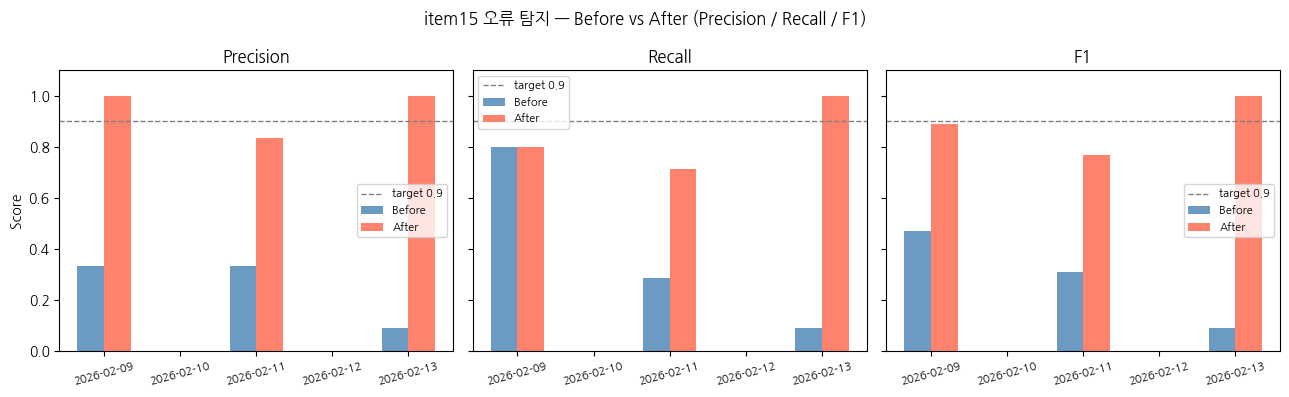

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
metrics = [("before_P", "after_P", "Precision"), ("before_R", "after_R", "Recall"), ("before_F1", "after_F1", "F1")]

for ax, (bk, ak, label) in zip(axes, metrics):
    x = range(len(df15))
    w = 0.35
    ax.bar([i - w/2 for i in x], df15[bk], w, label="Before", color="steelblue", alpha=0.8)
    ax.bar([i + w/2 for i in x], df15[ak], w, label="After",  color="tomato",    alpha=0.8)
    ax.axhline(0.9, color="gray", linestyle="--", linewidth=1, label="target 0.9")
    ax.set_xticks(list(x))
    ax.set_xticklabels(df15["date"], rotation=15, fontsize=8)
    ax.set_ylim(0, 1.1)
    ax.set_title(label)
    ax.legend(fontsize=8)

axes[0].set_ylabel("Score")
fig.suptitle("item15 오류 탐지 — Before vs After (Precision / Recall / F1)", fontsize=12)
plt.tight_layout()
plt.show()

## item15 — 로직 변경 이유 (Before / After)

### 핵심 문제: Before는 FP가 너무 많고, 동시에 FN도 많았다

| | Before avg | After avg |
|--|-----------|----------|
| FP (오탐) | **7.0** | **0.2** |
| TP (정탐) | 1.4 | 4.8 |
| F1 | 0.174 | 0.532 |

Before는 실제 오류 대응이 아닌 청크를 대거 candidate로 올리고(FP↑),  
동시에 실제 오류 대응 청크는 놓치는(FN↑) 이중 문제가 있었다.

---

### 변경 1 — 가정·개념 설명 표현 오탐 제거 (FP↓)

**Before의 문제**

`에러가?\s*(났|나|...)` 패턴이 가정·조건 표현까지 매칭했다.

| 표현 | Before | After |
|------|--------|-------|
| "에러가 났을 때 이렇게 해요" (개념 설명) | ✅ 매칭 (오탐) | ❌ 제외 |
| "오류가 나더라도 계속 진행해요" (조건) | ✅ 매칭 (오탐) | ❌ 제외 |
| "오류가 발생한다고 했죠" (설명) | ✅ 매칭 (오탐) | ❌ 제외 |
| "에러가 났어요" (실제 발생) | ✅ 매칭 | ✅ 매칭 |

**After의 수정**

negative lookahead로 가정/조건/설명 표현을 명시적으로 제외:
- `났(?!\s*을)` — "났을 때" 제외
- `나(?!더라|면|도)` — "나더라도", "나면" 제외
- `발생(?!한다)` — "발생한다" 제외

---

### 변경 2 — 도메인 특화 패턴 추가 (FN↓)

**Before의 문제**

DB/서버 실습 환경에서 자주 발생하는 오류 표현이 패턴에 없어서 실제 오류 대응 청크를 놓쳤다.

**After에 추가된 패턴**

| 카테고리 | 추가 패턴 예시 | 이유 |
|---------|--------------|------|
| DB 제약 | `제약\s*조건.{0,15}(위반\|걸리)` | FK/PK 위반 오류 탐지 |
| 락 | `(락\|lock).*걸[려]\s*(있어\|서)` | 트랜잭션 락 상황 탐지 |
| 서버 연결 | `서버\s*(죽\|꺼\|끊)`, `재접속` | 서버 다운/연결 오류 |
| 데이터 누락 | `빠졌`, `누락`, `중복` | INSERT/SELECT 결과 이상 |
| 설치 실패 | `(설치\|install)\s*안\s*됐` | 환경 설정 오류 |

---

### 변경 3 — 과도하게 광범위한 패턴 제거 (FP↓)

| Before 패턴 | 문제 | After |
|------------|------|-------|
| `안\s*되는(데\|거\|건)` | 일반 대화에서도 흔히 쓰임 | 제거 |
| `(이게\|이거)\s*문제` | "이게 문제를 낸 거야"(숙제) 오탐 | `(?![를로])` 추가 |
| `수정해서 보내주세요` | 연결어로 쓰이는 케이스 오탐 | `해(?!서)` 추가 |

---

### 결론

**Before**: 패턴이 광범위 → 오류와 무관한 일반 발화까지 candidate로 올림 (FP ↑)  
**After**: negative lookahead로 가정/설명 표현 제거 + DB/서버 도메인 패턴 보강 → FP↓ FN↓ 동시 달성

02-13 날짜가 가장 극적: Before F1=0.091(TP=1, FP=10) → After F1=1.000(TP=11, FP=0)

## item18 — 학생 질문 탐지

In [10]:
_LINE_RE = re.compile(r"^<(\d{2}:\d{2}:\d{2})>\s+(\S+):\s*(.*)$")

def parse_raw_stt(path):
    rows = []
    for line in path.read_text(encoding="utf-8").splitlines():
        m = _LINE_RE.match(line.strip())
        if not m: continue
        ts, sp, tx = m.group(1), m.group(2), m.group(3).strip()
        if tx: rows.append({"timestamp": ts, "speaker_id": sp, "text_raw": tx})
    return pd.DataFrame(rows)


def eval_item18_date(date, build_fn):
    gold_path = GOLDSET_DIR / "question" / f"{date}.json"
    raw_path  = RAW_DIR / f"{date}_{COURSE_ID}.txt"
    if not gold_path.exists() or not raw_path.exists():
        return None
    gold_qs = json.loads(gold_path.read_text()).get("gold", [])
    if not gold_qs:
        return None

    df = parse_raw_stt(raw_path)
    utterances = [
        Utterance(timestamp=str(r["timestamp"]), speaker_id=str(r["speaker_id"]),
                  text=str(r["text_raw"]), seconds_from_start=0)
        for _, r in df.iterrows()
    ]
    detected = [p["question"] for p in build_fn(utterances)]

    tp = fp = fn = 0
    for g in gold_qs:
        scores = [word_containment(g["text"], d) for d in detected]
        if scores and max(scores) >= MATCH_THRESHOLD:
            tp += 1
        else:
            fn += 1
    for d in detected:
        scores = [word_containment(g["text"], d) for g in gold_qs]
        if not scores or max(scores) < MATCH_THRESHOLD:
            fp += 1

    p  = tp / (tp + fp) if tp + fp > 0 else 0.0
    r  = tp / (tp + fn) if tp + fn > 0 else 0.0
    f1 = 2*p*r/(p+r) if p+r > 0 else 0.0
    return {"date": date, "gold": len(gold_qs), "TP": tp, "FN": fn, "FP": fp,
            "P": p, "R": r, "F1": f1}


rows18 = []
for date in EVAL_DATES:
    b = eval_item18_date(date, item18_before.build_qa_llm_payload)
    a = eval_item18_date(date, item18_after.build_qa_llm_payload)
    if b is None:
        continue
    rows18.append({
        "date":      date,
        "gold":      b["gold"],
        "before_P":  round(b["P"],  3),
        "before_R":  round(b["R"],  3),
        "before_F1": round(b["F1"], 3),
        "after_P":   round(a["P"],  3),
        "after_R":   round(a["R"],  3),
        "after_F1":  round(a["F1"], 3),
        "delta_F1":  round(a["F1"] - b["F1"], 3),
    })

df18 = pd.DataFrame(rows18)
display(df18)

,date,gold,before_P,before_R,before_F1,after_P,after_R,after_F1,delta_F1
0,2026-02-09,11,1.0,0.636,0.778,1.000,0.909,0.952,0.175
1,2026-02-10,2,1.0,1.000,1.000,1.000,1.000,1.000,0.000
2,2026-02-11,4,1.0,0.500,0.667,1.000,1.000,1.000,0.333
3,2026-02-12,2,0.5,0.500,0.500,1.000,1.000,1.000,0.500
4,2026-02-13,1,0.5,1.000,0.667,0.333,1.000,0.500,-0.167


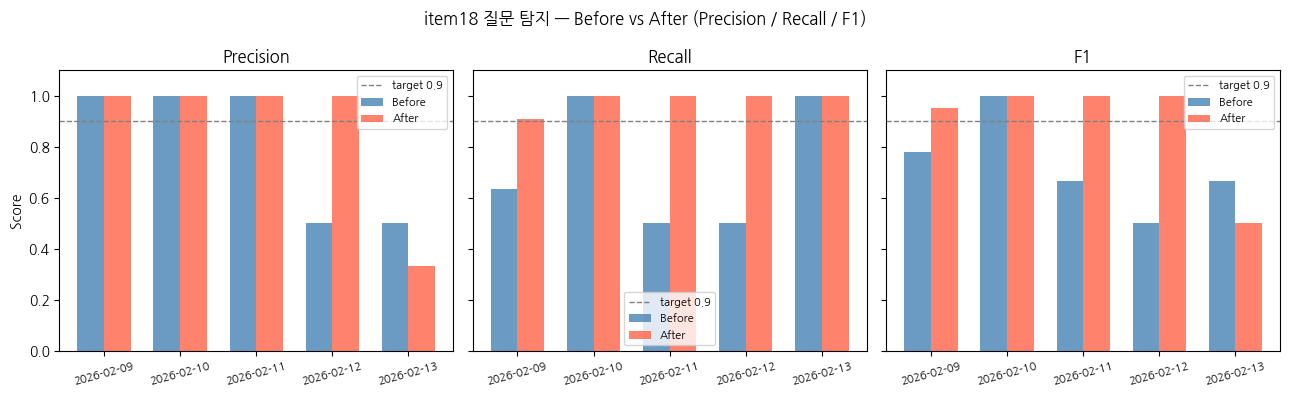

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
metrics = [("before_P", "after_P", "Precision"), ("before_R", "after_R", "Recall"), ("before_F1", "after_F1", "F1")]

for ax, (bk, ak, label) in zip(axes, metrics):
    x = range(len(df18))
    w = 0.35
    ax.bar([i - w/2 for i in x], df18[bk], w, label="Before", color="steelblue", alpha=0.8)
    ax.bar([i + w/2 for i in x], df18[ak], w, label="After",  color="tomato",    alpha=0.8)
    ax.axhline(0.9, color="gray", linestyle="--", linewidth=1, label="target 0.9")
    ax.set_xticks(list(x))
    ax.set_xticklabels(df18["date"], rotation=15, fontsize=8)
    ax.set_ylim(0, 1.1)
    ax.set_title(label)
    ax.legend(fontsize=8)

axes[0].set_ylabel("Score")
fig.suptitle("item18 질문 탐지 — Before vs After (Precision / Recall / F1)", fontsize=12)
plt.tight_layout()
plt.show()

## item18 — 로직 변경 이유 (Before / After)

### 핵심 문제: Before는 FN이 많았다 (Recall 부족)

|                | Before avg | After avg |
|----------------|-----------|----------|
| Recall         | **0.727**  | **0.982** |
| Precision      | 0.800      | 0.767     |
| F1             | 0.722      | 0.890     |

Before는 실제 질문 문장을 탐지하지 못하는 경우(FN)가 주된 문제였다.
After는 Recall이 크게 오르며 전반적 F1이 개선됐으나, 02-13 날짜에서
새 패턴이 FP를 유발해 오히려 F1이 하락(-0.167)했다.

---

### 변경 1 — 구어체 표현 범위 확장 (FN↓)

| Before 패턴 | After 패턴 | 이유 |
|------------|-----------|------|
| `강사님.{0,80}없어요` | `강사님.{0,80}(없는데\|없어요\|없어)` | 구어체 축약형 추가 |

---

### 변경 2 — 신규 패턴 추가 (FN↓)

**강사님 + 상황 표현 패턴**

| 추가 패턴 | 예시 | 이유 |
|---------|------|------|
| `강사님.{0,80}만약에` | "강사님 만약에 이렇게 하면 어떻게 돼요?" | 가정 질문 |
| `강사님.{0,80}이니까` | "강사님 이게 이니까 왜 이러는 거예요?" | 이유 질문 |
| `강사님.{0,80}다르게` | "강사님 다르게 하면 안 돼요?" | 대안 질문 |

**STT 오인식 변형 패턴**

| 추가 패턴 | 배경 |
|---------|------|
| `강산님.{0,80}(모르겠\|뭐야\|뭔가요\|...)` | "강사님" → "강산님" 오인식 |
| `강산이.{0,80}(안\s*돼\|그렇지\|맞지\|...)` | "강사님" → "강산이" 오인식 |

**강사님 없이 나타나는 명확한 질문**

| 추가 패턴 | 예시 |
|---------|------|
| `(이거\|이게)\s*(왜\|어떻게)\s*(이래요?\|그래요?)` | "이거 왜 이래요?" |

---

### 변경 3 — 오탐 제거 (FP↓)

| Before 패턴 | After 패턴 | 제외 표현 | 이유 |
|------------|-----------|---------|------|
| `물어보시는데` | `물어보시는데(?!\s*(말\s*하\|상관없))` | "물어보시는데 말하자면", "상관없" | 비질문 연결어 오탐 제거 |

---

### 결론

**Before**: 구어체·STT 변형·강사님 없는 질문 유형을 커버하지 못해 FN 다수  
**After**: 패턴 추가로 Recall 0.727 → 0.982 달성. Precision은 02-13에서 소폭 하락(FP +1)했으나 전체 F1은 0.722 → 0.890으로 개선

02-09·02-11·02-12에서 개선이 가장 뚜렷: F1 각각 +0.175, +0.333, +0.500


## 전체 요약

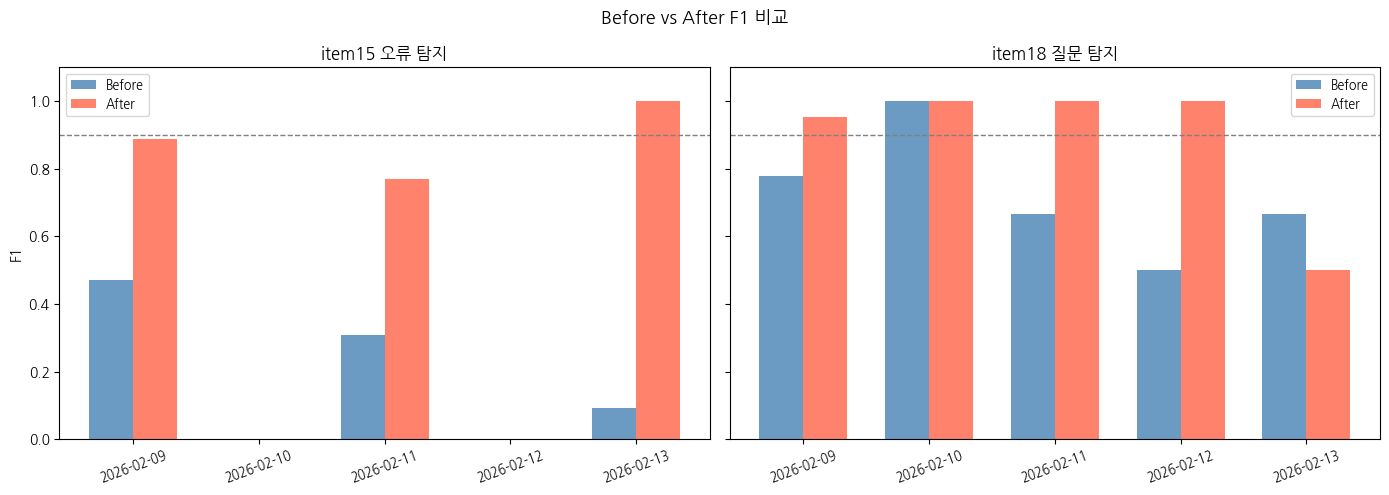


[ item15 ] 날짜별 ΔF1
  2026-02-09  Before=0.471  After=0.889  ↑0.418
  2026-02-10  Before=0.000  After=0.000  →0.000
  2026-02-11  Before=0.308  After=0.769  ↑0.462
  2026-02-12  Before=0.000  After=0.000  →0.000
  2026-02-13  Before=0.091  After=1.000  ↑0.909

[ item18 ] 날짜별 ΔF1
  2026-02-09  Before=0.778  After=0.952  ↑0.175
  2026-02-10  Before=1.000  After=1.000  →0.000
  2026-02-11  Before=0.667  After=1.000  ↑0.333
  2026-02-12  Before=0.500  After=1.000  ↑0.500
  2026-02-13  Before=0.667  After=0.500  ↓0.167


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, df, title in [
    (axes[0], df15, "item15 오류 탐지"),
    (axes[1], df18, "item18 질문 탐지"),
]:
    x = range(len(df))
    w = 0.35
    ax.bar([i - w/2 for i in x], df["before_F1"], w, label="Before", color="steelblue", alpha=0.8)
    ax.bar([i + w/2 for i in x], df["after_F1"],  w, label="After",  color="tomato",    alpha=0.8)
    ax.axhline(0.9, color="gray", linestyle="--", linewidth=1)
    ax.set_xticks(list(x))
    ax.set_xticklabels(df["date"], rotation=20, fontsize=9)
    ax.set_ylim(0, 1.1)
    ax.set_title(title)
    ax.legend(fontsize=9)

axes[0].set_ylabel("F1")
fig.suptitle("Before vs After F1 비교", fontsize=13)
plt.tight_layout()
plt.show()

print("\n[ item15 ] 날짜별 ΔF1")
for _, r in df15.iterrows():
    arrow = "↑" if r.delta_F1 > 0 else ("↓" if r.delta_F1 < 0 else "→")
    print(f"  {r.date}  Before={r.before_F1:.3f}  After={r.after_F1:.3f}  {arrow}{abs(r.delta_F1):.3f}")

print("\n[ item18 ] 날짜별 ΔF1")
for _, r in df18.iterrows():
    arrow = "↑" if r.delta_F1 > 0 else ("↓" if r.delta_F1 < 0 else "→")
    print(f"  {r.date}  Before={r.before_F1:.3f}  After={r.after_F1:.3f}  {arrow}{abs(r.delta_F1):.3f}")